In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants, units as u

from imf.cmf import hc13_mf

In [2]:
masses = np.logspace(-2,2,100) * u.M_sun

In [3]:
sizescales = np.array([1,2,5,20]) * u.pc
labels = [f'R = {v}' for v in sizescales]

In [4]:
cmfs = []
for scale in sizescales:
    cmfs.append((hc13_mf(masses,scale)).decompose())
cmfs = np.array(cmfs)

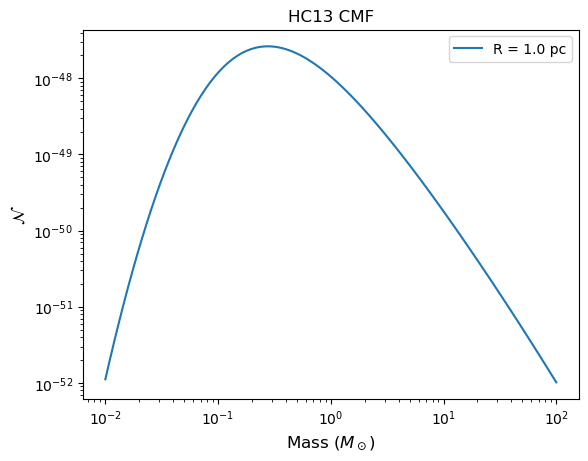

In [6]:
plt.figure()
plt.plot(masses,cmfs[0]*masses,label=labels[0])
plt.xscale('log')
plt.yscale('log')

plt.title(r'HC13 CMF')
plt.xlabel(r'Mass ($M_\odot$)',fontsize='large')
plt.ylabel(r'$\mathcal{N}$',fontsize='large')
plt.legend()

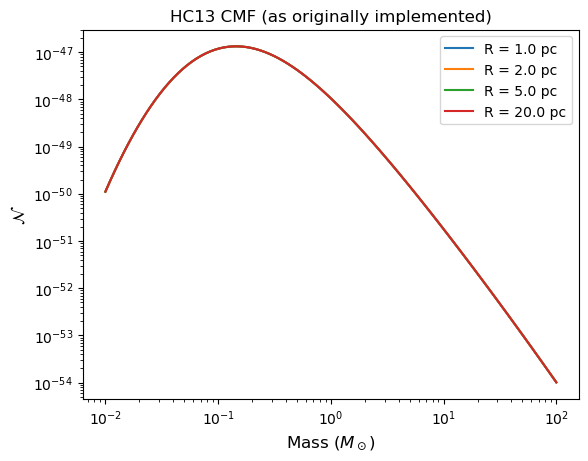

In [7]:
plt.figure()
plt.plot(masses,cmfs.T,label=labels)
plt.xscale('log')
plt.yscale('log')

plt.title(r'HC13 CMF')
plt.xlabel(r'Mass ($M_\odot$)',fontsize='large')
plt.ylabel(r'$\mathcal{N}$',fontsize='large')
plt.legend()

In [15]:
densities = np.array([5e3,3e4]) * u.cm**-3
labels = [r'$n_0$ = ' + f'{v}' for v in densities]

In [16]:
cmfs = []
for dens in densities:
    cmfs.append((hc13_mf(masses,meandens=dens)).decompose())
cmfs = np.array(cmfs)

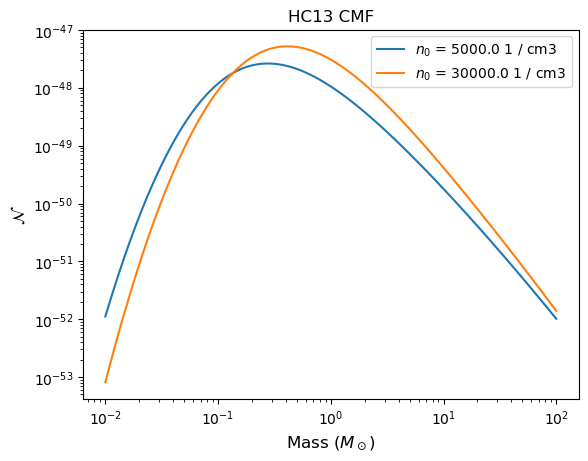

In [17]:
plt.figure()
plt.plot(masses,(cmfs * masses).T,label=labels)
plt.xscale('log')
plt.yscale('log')

plt.title(r'HC13 CMF')
plt.xlabel(r'Mass ($M_\odot$)',fontsize='large')
plt.ylabel(r'$\mathcal{N}$',fontsize='large')
plt.legend()

In [91]:
n17 = 3.8
alpha_ct = 0.75
mean_mol_wt = 2.33
V0=0.8 * u.km / u.s
meandens = 3e4 / u.cm**3
temperature = 10 * u.K
eta = 0.45
b_forcing = 0.4
Mach = 6

In [92]:
rho_bar = meandens * mean_mol_wt * constants.m_p

In [93]:
rho_bar.to(u.g/u.cm**3)

<Quantity 1.16916272e-19 g / cm3>

In [94]:
c_s = ((constants.k_B * temperature /
        (mean_mol_wt*constants.m_p))**0.5).to(u.km/u.s)

In [95]:
sig0_sq = np.log(1 + b_forcing**2 * Mach**2)

In [96]:
alpha_g = 3. / 5
phi_t = 2 * alpha_ct * np.sqrt(24 / alpha_g / np.pi**2)

In [97]:
a_j = np.pi**(5/2) / 6
C_m = 4 * np.pi / 3

In [98]:
M_j = (a_j / C_m * c_s**3 / np.sqrt(constants.G**3 * rho_bar)).to(u.M_sun)

In [99]:
M_j

<Quantity 0.39589244 solMass>

In [100]:
M_twid = (masses / M_j).decompose()

In [101]:
M_twid

<Quantity [2.52593860e-02, 2.77221449e-02, 3.04250198e-02, 3.33914217e-02,
           3.66470441e-02, 4.02200857e-02, 4.41414943e-02, 4.84452356e-02,
           5.31685862e-02, 5.83524577e-02, 6.40417503e-02, 7.02857419e-02,
           7.71385150e-02, 8.46594250e-02, 9.29136144e-02, 1.01972577e-01,
           1.11914777e-01, 1.22826330e-01, 1.34801746e-01, 1.47944749e-01,
           1.62369180e-01, 1.78199975e-01, 1.95574252e-01, 2.14642500e-01,
           2.35569879e-01, 2.58537651e-01, 2.83744753e-01, 3.11409516e-01,
           3.41771560e-01, 3.75093865e-01, 4.11665054e-01, 4.51801888e-01,
           4.95852015e-01, 5.44196974e-01, 5.97255507e-01, 6.55487182e-01,
           7.19396373e-01, 7.89536631e-01, 8.66515478e-01, 9.50999667e-01,
           1.04372096e+00, 1.14548247e+00, 1.25716559e+00, 1.37973769e+00,
           1.51426041e+00, 1.66189893e+00, 1.82393202e+00, 2.00176314e+00,
           2.19693258e+00, 2.41113079e+00, 2.64621306e+00, 2.90421557e+00,
           3.18737300e+00

In [102]:
L_j = ((np.pi**(3/2) / C_m)**(1/3) * c_s / np.sqrt(constants.G * rho_bar)).to(u.pc)

In [103]:
L_j

<Quantity 0.0759252 pc>

In [104]:
Mach_rel = V0 / c_s * (L_j.value)**eta / np.sqrt(3)
Mach_rel = np.sqrt(2)

In [105]:
Mach_rel

np.float64(1.4142135623730951)

In [106]:
from scipy.optimize import root_scalar

In [107]:
def R_side(R,M):
    return R * (1 + Mach_rel**2 * R**(2 * eta)) - M

def get_root(M):
    return root_scalar(R_side,x0=1,args=(M)).root

In [108]:
#R_twid = (0.1 * u.pc / L_j).decompose()
R_twid = np.vectorize(get_root)(masses.value)

In [109]:
L_i = (Mach / Mach_rel / np.sqrt(3))**(1 / eta) * L_j

In [110]:
sigma = sig0_sq * (1 - (R_twid * L_j / L_i)**(n17 - 3))

In [111]:
term1 = 2 / phi_t * rho_bar / M_j / R_twid**6
term2 = (1 + (1 - eta) * Mach_rel**2 * R_twid**(2*eta)) 
term3 = (1 + (2 * eta + 1) * Mach_rel**2 * R_twid**(2*eta))
term4 = (M_twid / R_twid**3)**(-1 - np.log(M_twid / R_twid**3) / 2 / sigma)
term5 = np.exp(-sigma / 8) / np.sqrt(2 * np.pi * sigma)

In [112]:
N = (term1 * term2 / term3 * term4 * term5 * (L_i)**3).decompose()

In [113]:
M_twid[np.nanargmax(N*masses)]

<Quantity 1.37973769>

In [114]:
masses[np.nanargmax(N*masses)]

<Quantity 0.54622772 solMass>

In [115]:
1 / (1 + b_forcing**2 * Mach**2)

0.14792899408284022

Text(0, 0.5, 'dN / d log M')

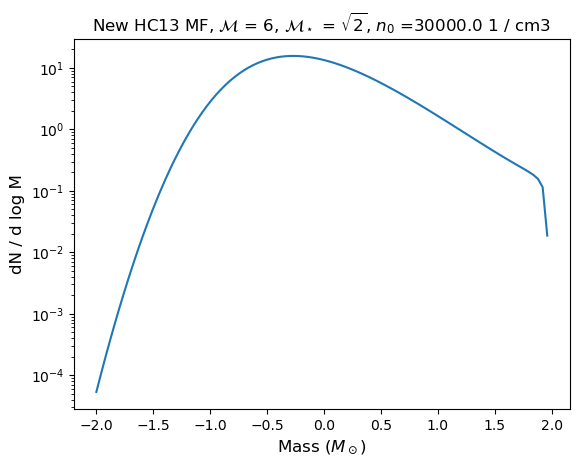

In [117]:
plt.figure()
plt.plot(np.log10(masses.value),N*masses)
#plt.xscale('log')
plt.yscale('log')
#plt.ylim(2e-1)
plt.title(r'New HC13 MF, $\mathcal{M}$ = 6, $\mathcal{M}_\star$ = $\sqrt{2}$, $n_0$ ='+ f'{meandens}',
         fontsize='large')
plt.xlabel(r'Mass ($M_\odot$)',fontsize='large')
plt.ylabel('dN / d log M',fontsize='large')